# How to Measure School Quality from Exam Results

**Context:** The Warsaw OKE district publishes results of the Polish 8th-grade exam (egzamin ósmoklasisty)
for every school each year. We have data from 2021 to 2025.

**Goal of this notebook:** Decide *which single number* best represents a school's quality,
given the data we have — and show the reasoning behind that choice.

**Why this matters:** The number we choose will colour the dots on a public map.
A bad choice can unfairly label a school as weak (or strong) due to statistical noise,
not real differences in teaching quality.

**Structure:**
1. Load data and show why only 3 subjects are usable
2. Choose the best per-year metric (mean, median, percentile, or difference from voivodeship)
3. Choose the best way to combine multiple years
4. Identify schools that are *consistently* in the top
5. Combine all 3 subjects into one score
6. Final metric definition

## 0. Setup

In [2]:
# Run with: uv run jupyter lab
from pathlib import Path
import re
import unicodedata
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data/egzamin-osmoklasisty')

CORE_SUBJECTS = ['polski', 'matematyka', 'angielski']
SUBJECT_LABELS = {
    'polski':    'Polish',
    'matematyka': 'Maths',
    'angielski': 'English',
}
SUBJECT_COLORS = {
    'polski':    '#2166ac',
    'matematyka': '#d6604d',
    'angielski': '#1a9850',
}

SHRINKAGE_K = 15

## 1. Load data

Each year's results come in a separate Excel file. We load them all and stack them
into one DataFrame where each row is one school in one year.

In [3]:
YEAR_FILE_RE = re.compile(r'^\d{4}', re.IGNORECASE)


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('ł', 'l').replace('Ł', 'L')  # ł has no NFKD decomposition
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    lvl0_values, lvl1_values = [], []
    last_lvl0 = 'meta'
    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)
        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw).removeprefix('jezyk ')
        lvl0_values.append(last_lvl0)
        lvl1_values.append(normalize_text(lvl1_raw) if lvl1_raw else 'value')
    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['subject', 'metric'])


def read_exam_file(path: Path) -> pd.DataFrame:
    year = int(YEAR_FILE_RE.match(path.name).group(0))
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    df[('meta', 'year')] = year
    return df


files = sorted(p for p in DATA_DIR.glob('*.xlsx*') if YEAR_FILE_RE.match(p.name))
assert files, f'No data files found in {DATA_DIR}'

raw_frames = [read_exam_file(p) for p in files]
df_raw = pd.concat(raw_frames, ignore_index=True)

years = [int(YEAR_FILE_RE.match(p.name).group(0)) for p in files]
print(f'Loaded {len(files)} files: {years}')
print(f'Total rows: {len(df_raw):,}  (one row = one school × one year)')

Loaded 5 files: [2021, 2022, 2023, 2024, 2025]
Total rows: 8,260  (one row = one school × one year)


In [4]:
# Build a flat working DataFrame with consistent column names
# Each subject contributes 3 columns: n_students, median_pct, mean_pct
ALL_SUBJECTS = ['polski', 'matematyka', 'angielski', 'francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

records = {}
records['rspo']        = df_raw[('meta', 'rspo')]
records['year']        = df_raw[('meta', 'year')]
records['school_name'] = df_raw[('meta', 'nazwa szkoly')]
records['is_public'] = df_raw.get(('meta', 'czy publiczna'), pd.Series(dtype=str))
records['gmina']     = df_raw.get(('meta', 'gmina - nazwa'), pd.Series(dtype=str))
records['powiat']    = df_raw.get(('meta', 'powiat - nazwa'), pd.Series(dtype=str))

for subject_code in ALL_SUBJECTS:
    records[f'n_{subject_code}']      = pd.to_numeric(df_raw[(subject_code, 'liczba zdajacych')])
    records[f'median_{subject_code}'] = pd.to_numeric(df_raw[(subject_code, 'mediana (%)')])
    records[f'mean_{subject_code}']   = pd.to_numeric(df_raw[(subject_code, 'wynik sredni (%)')])

df = pd.DataFrame(records)
df = df[df['n_polski'].notna() & (df['n_polski'] > 0)].copy()
print(f'Working dataset: {len(df):,} rows, {df["rspo"].nunique():,} unique schools')
print(f'Columns with data: {[c for c in df.columns if c.startswith("n_")]}')

Working dataset: 8,259 rows, 1,790 unique schools
Columns with data: ['n_polski', 'n_matematyka', 'n_angielski', 'n_francuski', 'n_hiszpanski', 'n_niemiecki', 'n_rosyjski', 'n_wloski']


### Remove rows with missing data in core subjects

In [5]:
# ── H1: does n < 5 students → missing median/mean? ───────────────────────────
print('H1: % missing median by student count group\n')
h1_rows = []
for subject in CORE_SUBJECTS:
    n_col, median_column = f'n_{subject}', f'median_{subject}'
    tmp = df[[n_col, median_column]].dropna(subset=[n_col])
    for lower_bound, upper_bound, label in [(0, 5, 'n < 5'), (5, 10, '5 ≤ n < 10'), (10, None, 'n ≥ 10')]:
        mask = (tmp[n_col] < upper_bound) if upper_bound else (tmp[n_col] >= lower_bound)
        mask &= (tmp[n_col] >= lower_bound)
        sub = tmp[mask]
        h1_rows.append({
            'subject': SUBJECT_LABELS[subject],
            'group': label,
            'rows': len(sub),
            '% missing median': f"{sub[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h1_rows)
    .pivot(index='group', columns='subject', values='% missing median')
    .loc[['n < 5', '5 ≤ n < 10', 'n ≥ 10']]
)

# ── H2: does 2021 have more missing data for n ≥ 5 schools? ──────────────────
print('\nH2: % missing median for schools with n ≥ 5, by year\n')
h2_rows = []
for year in sorted(df['year'].unique()):
    yr = df[df['year'] == year]
    for subject in CORE_SUBJECTS:
        n_col, median_column = f'n_{subject}', f'median_{subject}'
        subset = yr[yr[n_col] >= 5]
        h2_rows.append({
            'year': year,
            'subject': SUBJECT_LABELS[subject],
            'n ≥ 5': len(subset),
            'missing median': subset[median_column].isna().sum(),
            '% missing': f"{subset[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h2_rows)
    .pivot(index='year', columns='subject', values='% missing')
)

H1: % missing median by student count group



subject,English,Maths,Polish
group,,,
n < 5,100.0%,100.0%,100.0%
5 ≤ n < 10,21.3%,20.9%,21.0%
n ≥ 10,0.0%,0.0%,0.0%



H2: % missing median for schools with n ≥ 5, by year



subject,English,Maths,Polish
year,,,
2021,18.7%,18.0%,18.1%
2022,0.0%,0.0%,0.0%
2023,0.0%,0.0%,0.0%
2024,0.0%,0.0%,0.0%
2025,0.0%,0.0%,0.0%


In [6]:
# ── Drop rows missing core subject data ───────────────────────────────────────
complete_mask = pd.Series(True, index=df.index)
for subject in CORE_SUBJECTS:
    complete_mask &= df[f'median_{subject}'].notna()
    complete_mask &= df[f'mean_{subject}'].notna()

df_rejected = df[~complete_mask].copy()
df = df[complete_mask].copy()

def missing_subjects(row):
    return ', '.join(
        s for s in CORE_SUBJECTS
        if pd.isna(row[f'median_{s}']) or pd.isna(row[f'mean_{s}'])
    )

df_rejected['missing_subjects'] = df_rejected.apply(missing_subjects, axis=1)

print(f'Rejected: {len(df_rejected):,} rows  |  kept: {len(df):,}')
print()
print('Rejected rows by year:')
_totals = df.groupby('year')['rspo'].count().rename('total')
_rej    = df_rejected.groupby('year').agg(rows=('rspo', 'count'), unique_schools=('rspo', 'nunique'))
_rej['% of year'] = (_rej['rows'] / (_rej['rows'] + _totals) * 100).round(1).astype(str) + '%'
display(_rej)

# Export
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
export_cols = (
    ['rspo', 'school_name', 'year', 'missing_subjects']
    + [f'{m}_{s}' for s in CORE_SUBJECTS for m in ['n', 'median', 'mean']]
)
rej = df_rejected[[c for c in export_cols if c in df_rejected.columns]]
rej.to_csv(output_dir / 'rejected_schools.csv', index=False)
rej.to_excel(output_dir / 'rejected_schools.xlsx', index=False)
print(f'\nSaved {len(rej):,} rows → {output_dir}/rejected_schools.{{csv,xlsx}}')

Rejected: 774 rows  |  kept: 7,485

Rejected rows by year:


,rows,unique_schools,% of year
year,,,
2021,388,388,23.5%
2022,71,71,4.2%
2023,63,63,3.7%
2024,145,145,9.2%
2025,107,107,6.4%



Saved 774 rows → ../outputs/rejected_schools.{csv,xlsx}


## 2. Why only Polish, Maths, and English?

All students take Polish, Maths, and English. The other foreign languages
(French, German, Spanish, Russian, Italian) are taken by a small minority —
so we can't meaningfully compare schools on those.

Below is histogram of numbers of students taking exam in all data (so each school is counted for each year).
We already removed small schools for which we had no mean / median data in source files.

In [7]:
# ECDF of student counts per school-year for all subjects
all_subjects_short = {
    'polski':    'Polish',
    'matematyka':'Maths',
    'angielski': 'English',
    'francuski': 'French',
    'hiszpanski':'Spanish',
    'niemiecki': 'German',
    'rosyjski':  'Russian',
    'wloski':    'Italian',
}

core_short    = ['polski', 'matematyka', 'angielski']
minority_short= ['francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

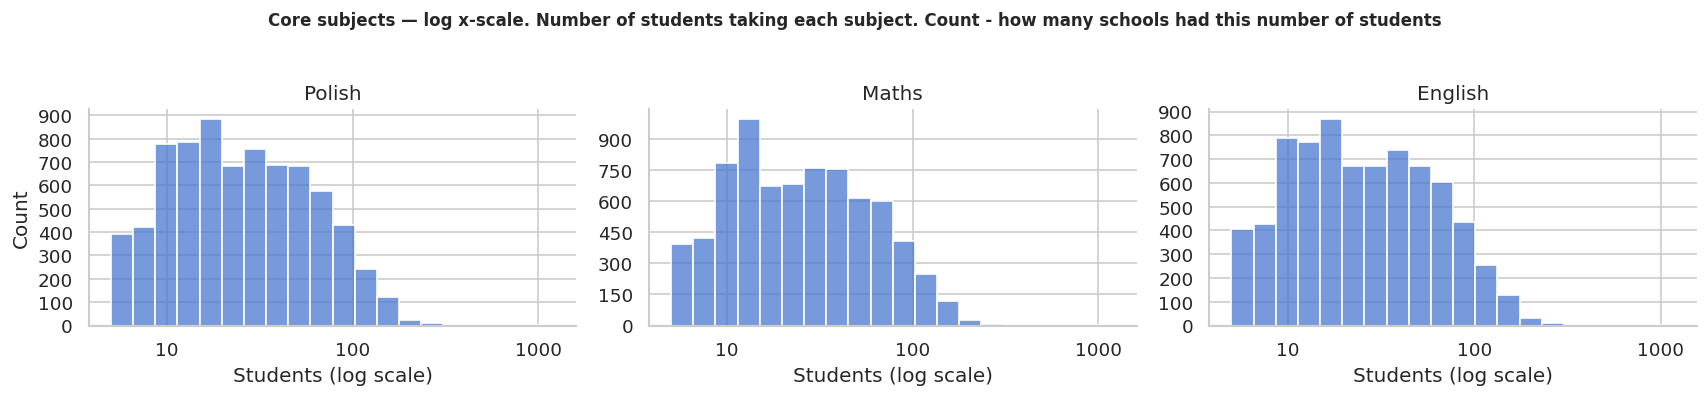

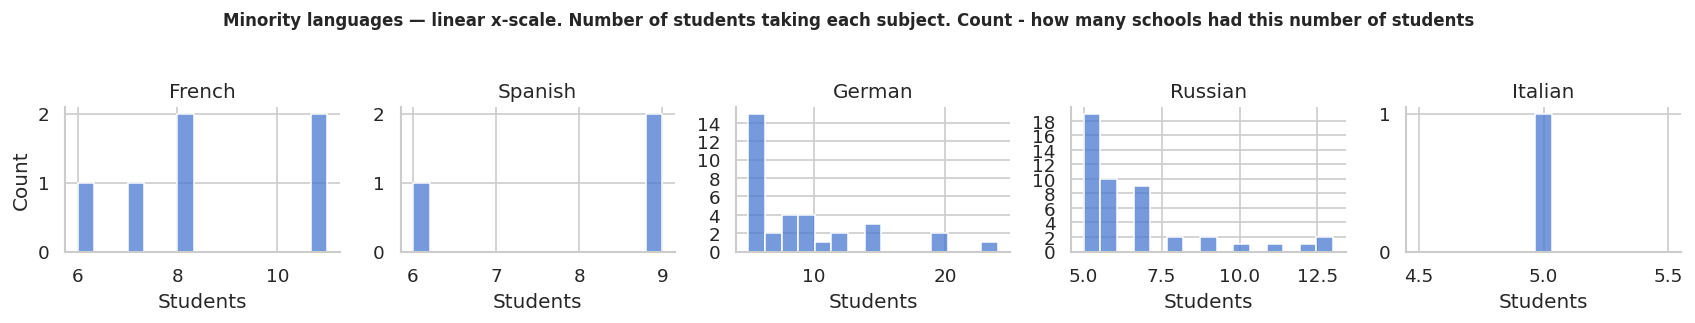


Minority languages — records with valid median data (n ≥ 5):


,School-year records,Median students,Max students
Subject,,,
French,6,8,11
Spanish,3,9,9
German,34,7,24
Russian,47,6,13
Italian,1,5,5


In [8]:
# ── Core subjects: log x-scale | Minority languages: linear x-scale ──────────
long_core = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in core_short if f'n_{s}' in df.columns
]).dropna()
long_core['Language'] = pd.Categorical(
    long_core['Language'],
    categories=[all_subjects_short[s] for s in core_short],
    ordered=True,
)

long_min = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in minority_short if f'n_{s}' in df.columns
]).dropna()
long_min['Language'] = pd.Categorical(
    long_min['Language'],
    categories=[all_subjects_short[s] for s in minority_short if f'n_{s}' in df.columns],
    ordered=True,
)

# Core — log x-scale
g1 = sns.FacetGrid(long_core, col='Language', col_wrap=3,
                   sharex=False, sharey=False, height=3.2, aspect=1.5)
g1.map(sns.histplot, 'Students', bins=20, log_scale=(True, False))
g1.set_titles('{col_name}')
g1.set_axis_labels('Students (log scale)', 'Count')
for ax in g1.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
g1.figure.suptitle('Core subjects — log x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(long_min, col='Language', col_wrap=5,
                  sharex=False, sharey=False, height=2.6, aspect=1.1)
g.map(sns.histplot, 'Students', bins=15)
g.set_titles('{col_name}')
g.set_axis_labels('Students', 'Count')
for ax in g.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.figure.suptitle('Minority languages — linear x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── Summary table for minority languages (only records with valid median, i.e. n ≥ 5) ──
rows = []
for subject_code in minority_short:
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    s = df.loc[df[f'median_{subject_code}'].notna(), col].dropna()
    if s.empty:
        continue
    rows.append({
        'Subject':             all_subjects_short[subject_code],
        'School-year records': len(s),
        'Median students':     int(s.median()),
        'Max students':        int(s.max()),
    })
print('\nMinority languages — records with valid median data (n ≥ 5):')
display(pd.DataFrame(rows).set_index('Subject'))

### Distribution of students count per school

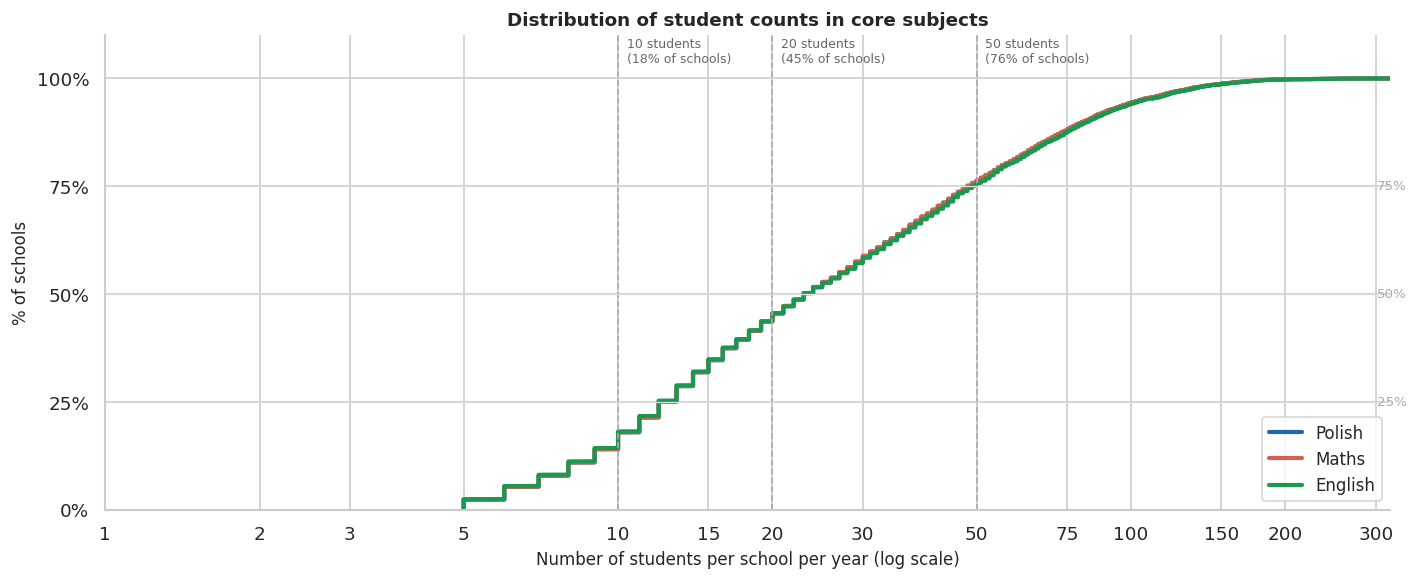

In [9]:
# ── ECDF for the 3 core subjects ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

core_colors = ['#2166ac', '#d6604d', '#1a9850']
for subject_code, color in zip(core_short, core_colors):
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    x = np.sort(df[col].dropna().values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    ax.plot(x, y, label=all_subjects_short[subject_code], color=color, lw=2.5)

# Reference lines — percentages computed from actual n_polski distribution
_n_ref = df['n_polski'].dropna().values
for thresh in [10, 20, 50]:
    pct = ((_n_ref <= thresh).mean() * 100)
    ax.axvline(thresh, color='#aaa', ls='--', lw=1)
    ax.text(thresh * 1.04, 103,
            f'{thresh} students\n({pct:.0f}% of schools)',
            fontsize=7.5, color='#666', va='bottom')

for ref in [25, 50, 75]:
    ax.axhline(ref, color='#ddd', lw=0.8)
    ax.text(302, ref, f'{ref}%', fontsize=8, color='#aaa', va='center', ha='left')

ax.set_xscale('log')
ticks = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
ax.set_xticks(ticks)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim(1, 320)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.set_xlabel('Number of students per school per year (log scale)', fontsize=10)
ax.set_ylabel('% of schools', fontsize=10)
ax.set_title('Distribution of student counts in core subjects', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** Almost half of all schools have no more than 20 students sitting any given exam in any given year.
For around one fifth of schools, this number is not more than 10. This matters a lot for how we measure quality (couple good/bad students can strongly affect school results).

## 3. Choosing the best per-year metric

### The problem with raw scores

The exam difficulty changes year to year. In 2021, the voivodeship median for Maths was **46 pp**;
in 2022 it jumped to **60 pp**. A school scoring 55 pp in both years looks stable,
but in 2021 it was 9 pp *above* average and in 2022 it was 5 pp *below* average.
Raw scores alone can't tell us how a school is doing relative to its peers.

Below we show three views of the problem:
1. Year-to-year shifts in the voivodeship-wide distribution (next chart)
2. Why the median of medians jumps more than the mean of means (after that)
3. Within a single school, how much do results swing year to year? (after that)

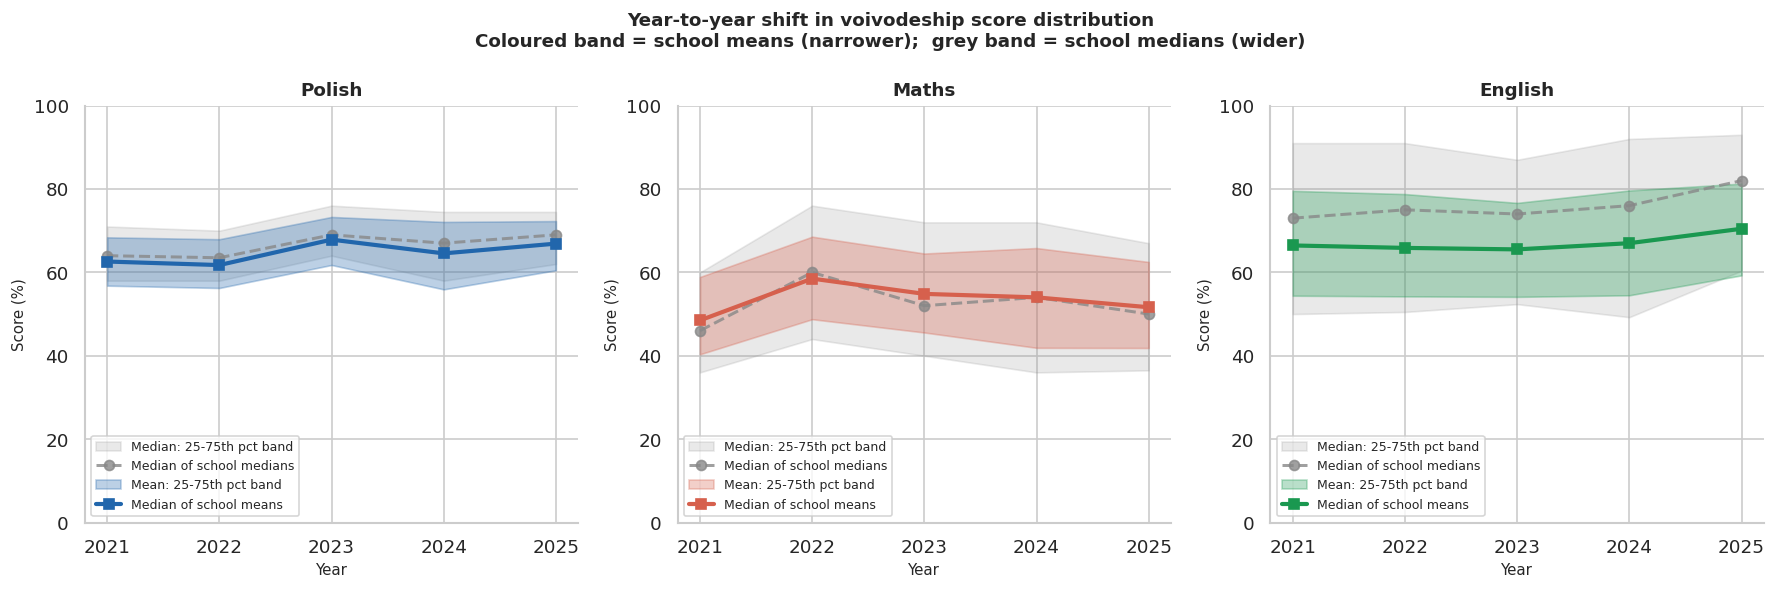

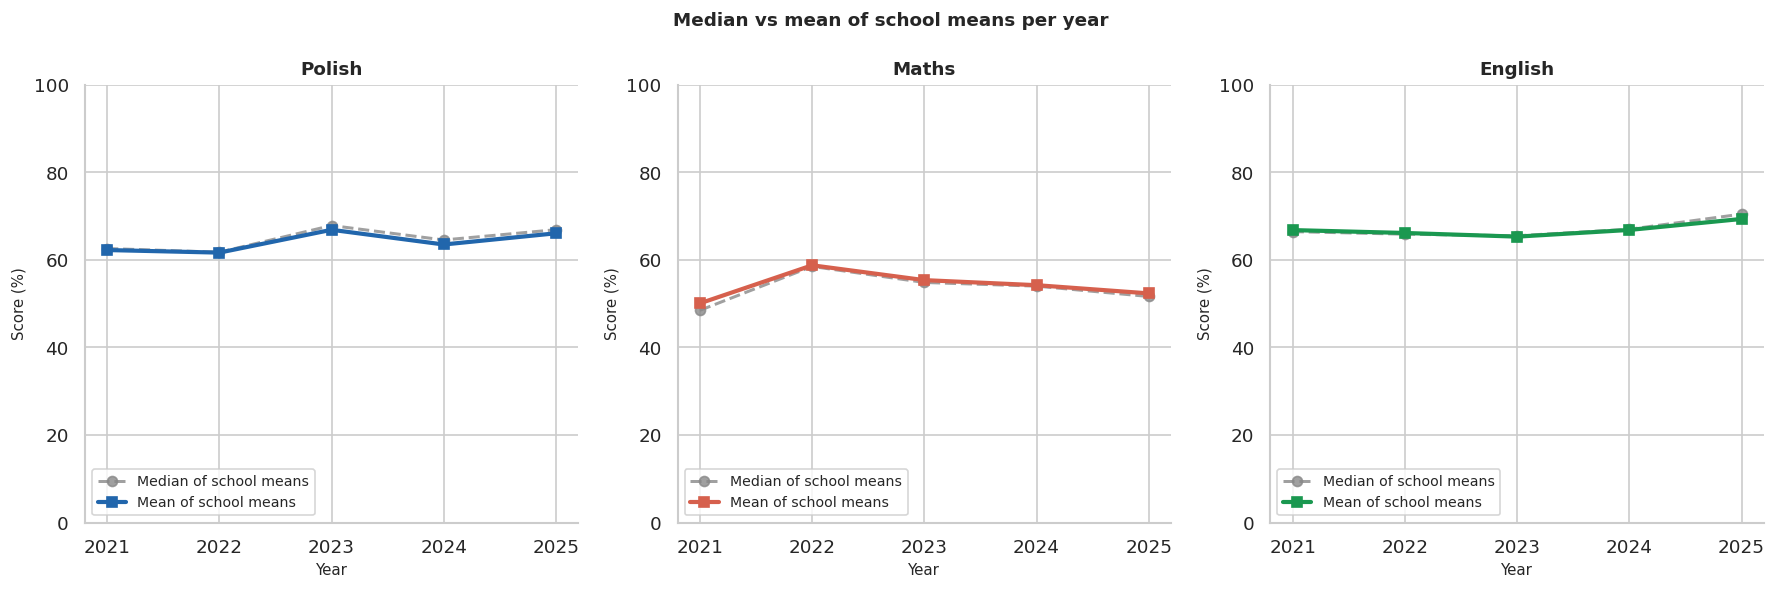

Median of school medians:


,Polish,Maths,English
year,,,
2021,64.0,46.0,73.0
2022,63.5,60.0,75.0
2023,69.0,52.0,74.0
2024,67.0,54.0,76.0
2025,69.0,50.0,82.0



Median of school means:


,Polish,Maths,English
year,,,
2021,62.6,48.5,66.5
2022,61.8,58.5,65.9
2023,67.9,54.8,65.5
2024,64.6,54.0,67.0
2025,66.9,51.6,70.5



Mean of school means:


,Polish,Maths,English
year,,,
2021,62.2,50.1,66.8
2022,61.7,58.8,66.1
2023,66.9,55.4,65.3
2024,63.5,54.2,66.8
2025,66.1,52.3,69.3



Year-to-year range (max - min across 5 years) -- smaller = more stable:


,Polish,Maths,English
Median of mediana range (pp),5.5,14.0,9.0
Mean of means range (pp),5.2,8.7,4.0


In [10]:
# Year-to-year voivodeship distribution: school medians (grey) vs school means (coloured)
years     = sorted(df['year'].unique())
n_years = len(years)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]

    grouped_median  = df.groupby('year')[f'median_{subject}']
    grouped_mean = df.groupby('year')[f'mean_{subject}']

    q25_median = grouped_median.quantile(0.25).values
    q50_median = grouped_median.quantile(0.50).values
    q75_median = grouped_median.quantile(0.75).values

    q25_avg = grouped_mean.quantile(0.25).values
    q50_avg = grouped_mean.quantile(0.50).values
    q75_avg = grouped_mean.quantile(0.75).values

    ax.fill_between(years, q25_median, q75_median, alpha=0.18, color='#888888',
                    label='Median: 25-75th pct band')
    ax.plot(years, q50_median, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school medians')
    ax.fill_between(years, q25_avg, q75_avg, alpha=0.30, color=color,
                    label='Mean: 25-75th pct band')
    ax.plot(years, q50_avg, 's-', lw=2.5, color=color,
            label='Median of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Year-to-year shift in voivodeship score distribution\n'
    'Coloured band = school means (narrower);  grey band = school medians (wider)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()
# Median of school means vs mean of school means
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]
    grouped_mean = df.groupby('year')[f'mean_{subject}']

    q50_avg  = grouped_mean.quantile(0.50).values
    mean_avg = grouped_mean.mean().values

    ax.plot(years, q50_avg, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school means')
    ax.plot(years, mean_avg, 's-', lw=2.5, color=color,
            label='Mean of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Median vs mean of school means per year', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median of school medians:')
voivodeship_median_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'median_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_median_table.round(1))

print('\nMedian of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print('\nMean of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].mean()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print(f'\nYear-to-year range (max - min across {n_years} years) -- smaller = more stable:')
median_range = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'median_{s}'].median().max()
    - df.groupby('year')[f'median_{s}'].median().min(), 1)
    for s in CORE_SUBJECTS}
mean_range = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'mean_{s}'].mean().max()
    - df.groupby('year')[f'mean_{s}'].mean().min(), 1)
    for s in CORE_SUBJECTS}
display(pd.DataFrame({'Median of mediana range (pp)': median_range,
                      'Mean of means range (pp)':   mean_range}).T)

#### Why does the median jumps more than mean?

1. If we consider only school means as expected when exam is easy (Polish, English) typically bad students push the mean down so mean is below median.
With hard subjects like Math situation is opposite - middle student has lower score so good students push mean higher than median.
We also see that in years were Math exam got easier the difference decreased.
2. But why median which in some settings is more stable than mean, here jumps way more?

**Why does the voivodeship median of medians in Maths jumps 14 pp while the voivodeship median of means moves only 10 pp?**

For Maths between 2021 and 2022, the voivodeship median of medians jumped from 46 to 60 (14 pp),
while the voivodeship median of means moved only from 48.5 to 58.5 (10 pp). What explains this 4 pp gap?

It's not random noise, and it's not just quantization (school medians come in 2 pp steps,
which can explain at most 1-2 pp of the jump). The real explanation requires looking
at how *individual* schools moved between the two years.

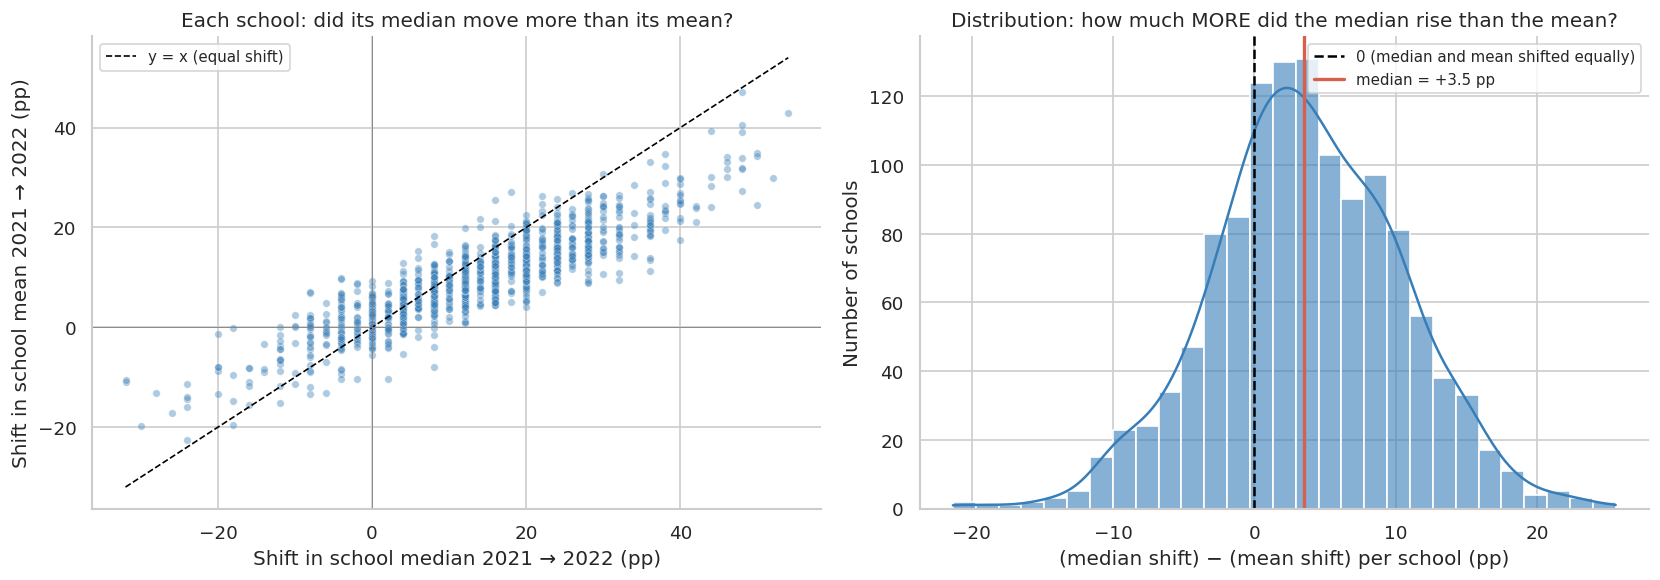

Schools tracked across 2021→2022: 1,247
Median shift in school medians: +14.0 pp
Median shift in school means:   +10.0 pp
Median of (median_shift − mean_shift): +3.5 pp
% schools where median rose more than mean: 71%


In [11]:
# Track the SAME schools across 2021 and 2022 — how much did each shift?
sub_2021 = df[df['year'] == 2021].set_index('rspo')
sub_2022 = df[df['year'] == 2022].set_index('rspo')
common = sub_2021.index.intersection(sub_2022.index)

median_shift = sub_2022.loc[common, 'median_matematyka'] - sub_2021.loc[common, 'median_matematyka']
shift_avg = sub_2022.loc[common, 'mean_matematyka']   - sub_2021.loc[common, 'mean_matematyka']
shift_math_df = pd.DataFrame({'median_shift': median_shift, 'shift_avg': shift_avg})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: shift in median vs shift in mean ---
ax = axes[0]
sns.scatterplot(data=shift_math_df, x='median_shift', y='shift_avg',
                ax=ax, alpha=0.4, s=20, color='#377eb8')

# Reference line y = x (where median and mean shifts would be equal)
x_min = min(shift_math_df.min().min(), -5)
x_max = max(shift_math_df.max().max(), 5)
ax.plot([x_min, x_max], [x_min, x_max], color='black', ls='--', lw=1,
        label='y = x (equal shift)')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Shift in school median 2021 → 2022 (pp)')
ax.set_ylabel('Shift in school mean 2021 → 2022 (pp)')
ax.set_title('Each school: did its median move more than its mean?')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Most points sit BELOW the y=x line → median rose more than the mean

# --- Histogram: median shift minus mean shift ---
ax = axes[1]
diff = median_shift - shift_avg
sns.histplot(diff, kde=True, ax=ax, color='#377eb8', alpha=0.6)
ax.axvline(0, color='black', ls='--', lw=1.5,
           label='0 (median and mean shifted equally)')
ax.axvline(diff.median(), color='#d6604d', lw=2,
           label=f'median = {diff.median():+.1f} pp')
ax.set_xlabel('(median shift) − (mean shift) per school (pp)')
ax.set_ylabel('Number of schools')
ax.set_title('Distribution: how much MORE did the median rise than the mean?')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Numeric summary
print(f'Schools tracked across 2021→2022: {len(common):,}')
print(f'Median shift in school medians: {median_shift.median():+.1f} pp')
print(f'Median shift in school means:   {shift_avg.median():+.1f} pp')
print(f'Median of (median_shift − mean_shift): {(median_shift - shift_avg).median():+.1f} pp')
print(f'% schools where median rose more than mean: {((median_shift - shift_avg) > 0).mean()*100:.0f}%')

#### How did individual schools move 2021 → 2022?

**Left:** Each dot is one school. The X-axis is how much that school's median moved
between 2021 and 2022. The Y-axis is how much its mean moved. If both metrics
captured the same thing, dots would sit on the dashed y = x line.

The dots sit consistently *below* the line — meaning for almost every school, the
median rose **more** than the mean. The exam got easier, but the median student
benefited more than the average student.

**Right:** The same fact shown as a distribution. We plot (median shift) − (mean shift)
for each school. If this difference were near zero, the two metrics would behave
similarly. Instead the distribution is clearly shifted to the right of zero —
the median rose about 4 pp more than the mean for the typical school.

**Why does this happen?**

The mean averages over the whole class, including students at both extremes.
When the exam got easier, the strong students were already near 90–100% — they
couldn't gain as much (ceiling effect). The mean reflects this dampening.

The median is the score of the *middle* student. When the difficulty shifts,
this middle student's score moves by the full amount of the shift, because they
weren't pressed against the ceiling. So the median captures the shift in full,
the mean captures it after ceiling/floor effects dampen the extremes.

**Implication for the metric:**

The voivodeship mean is a more *linear* function of exam difficulty than the
voivodeship median — it absorbs ceiling and floor effects proportionally.
Subtracting the voivodeship mean from each school's mean (`diff_avg`) gives a
cleaner residual signal about that school's performance, relative to the
voivodeship in that year. Subtracting the voivodeship median (`diff_med`) leaves
residuals contaminated by the non-linear response of the median to difficulty
shifts. This is one more reason `diff_avg` beats `diff_med` in LOO stability.

#### How much does a single school swing year to year?

So far we looked at the voivodeship-wide distribution. Now: when we follow a
single school through 3+ years, how much does its result move?
And does the median or mean swing more *within a single school*?

This matters because it sets a floor on how precise our ranking can be: if a typical
school's median moves by 24 pp year to year, then a 5 pp difference between two
schools is comfortably within the noise.

Within-school year-to-year range of mean score (pp), schools with >= 3 years:
voi_range = voivodeship-wide year-to-year range (baseline).



,voi_range (pp),P25 (pp),P50 (pp),P75 (pp),P90 (pp),P95 (pp)
subject,,,,,,
Polish,5.2,9.1,12.9,18.1,23.5,26.1
Maths,8.7,11.9,16.3,22.4,29.3,34.1
English,4.0,8.4,13.2,19.7,27.7,33.0


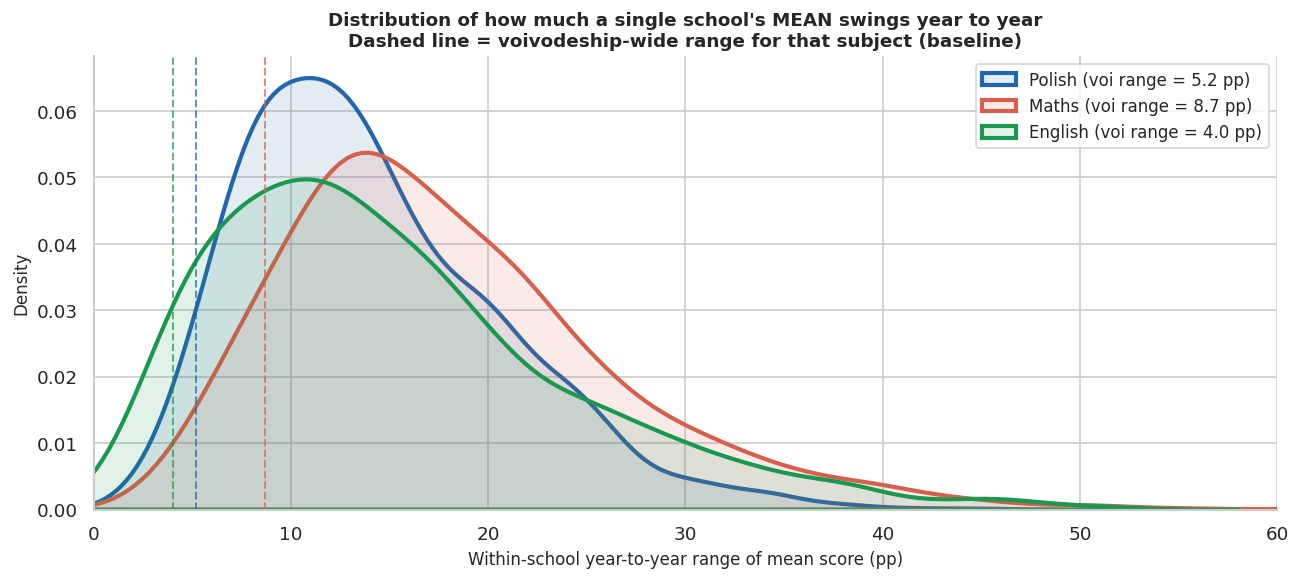

In [12]:
# ── Within-school year-to-year variation of the school mean ──────────────────
# Schools with >= 3 years of data give meaningful range/std.
# We focus on the mean since diff_avg / unit_norm_diff_avg won the LOO test.
year_count_for_swing = df.groupby('rspo')['year'].nunique()
df_swing = df[df['rspo'].isin(year_count_for_swing[year_count_for_swing >= 3].index)].copy()

# Per-school range (max - min) of mean score across the school's years
swing_records = []
for subject in core_short:
    mean_range = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min())
    voi_avg_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                     - df.groupby('year')[f'mean_{subject}'].mean().min())
    row = {
        'subject':         SUBJECT_LABELS[subject],
        'voi_range (pp)':  round(voi_avg_range, 1),
    }
    for pct in [25, 50, 75, 90, 95]:
        row[f'P{pct} (pp)'] = round(np.percentile(mean_range.dropna(), pct), 1)
    swing_records.append(row)

swing_df = pd.DataFrame(swing_records).set_index('subject')
print("Within-school year-to-year range of mean score (pp), schools with >= 3 years:")
print("voi_range = voivodeship-wide year-to-year range (baseline).\n")
display(swing_df)

# ── Distribution of within-school mean range, per subject ───────────────────
# How wide is the band of mean-score swings for each subject?
fig, ax = plt.subplots(figsize=(11, 5))

for subject in core_short:
    rng = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min()).dropna()
    voi_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                 - df.groupby('year')[f'mean_{subject}'].mean().min())

    sns.kdeplot(rng, ax=ax, color=SUBJECT_COLORS[subject], lw=2.5,
                label=f'{SUBJECT_LABELS[subject]} (voi range = {voi_range:.1f} pp)',
                fill=True, alpha=0.12)

    # Mark the voivodeship-wide range as a vertical line in matching colour
    ax.axvline(voi_range, color=SUBJECT_COLORS[subject], lw=1.2, ls='--', alpha=0.7)

ax.set_xlabel('Within-school year-to-year range of mean score (pp)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title(
    'Distribution of how much a single school\'s MEAN swings year to year\n'
    'Dashed line = voivodeship-wide range for that subject (baseline)',
    fontsize=11, fontweight='bold')
ax.set_xlim(0, 60)
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the table shows:**

- **Single schools swing 1.7–2.6x more than the voivodeship-wide trend.** For the median
  school in Maths, results move 24 pp year to year, while the voivodeship-wide median
  moves 14 pp. Schools are individually noisier than the trend.
- **Maths has the smallest school/voivodeship ratio (1.7x at P50)**, despite the largest
  voivodeship swing (14 pp). This means much of the Maths year-to-year movement
  is "everybody shifted together" (driven by exam difficulty), not individual school
  variation. After we normalise by the voivodeship reference, Maths becomes much cleaner.
- **Polish and English ratios are 2.3-2.6x at P50 and reach 5.6-5.9x at P95.** Schools
  in these subjects are much more individually noisy than the voivodeship-wide trend.
- **Median swings more than mean inside each school.** For Maths the typical school
  median range is 24 pp vs 16 pp for the mean (47% wider); for English 21 vs 13 pp
  (59% wider). This is the same effect we saw in the 2021→2022 example — the median
  responds more aggressively to year-to-year changes in difficulty and cohort.

**Concrete example.** A "median" school in Maths has its full-data score somewhere
around the 50th percentile of the ranking — let's say its 5-year mean score is 52 pp.
With a year-to-year range of 24 pp, its best year might show 64 pp (~ 80th percentile)
and its worst year might show 40 pp (~ 20th percentile). The school's "true" position
in the ranking is anywhere across a 60-percentile-wide band depending on which year
you happen to look at.

**Implication:** We need a metric that *normalises by year* to subtract off most of
this voivodeship-wide noise, and we need to *aggregate across multiple years* to reduce
the within-school cohort noise. A single-year ranking will be dominated by luck.

**Real schools — examples of year-to-year swings**

To make the numbers concrete, let's pick a few real schools from the dataset
and look at how their mean score moved year by year. We sample across the
range of swing magnitudes — calm schools, typical schools, and very volatile ones.

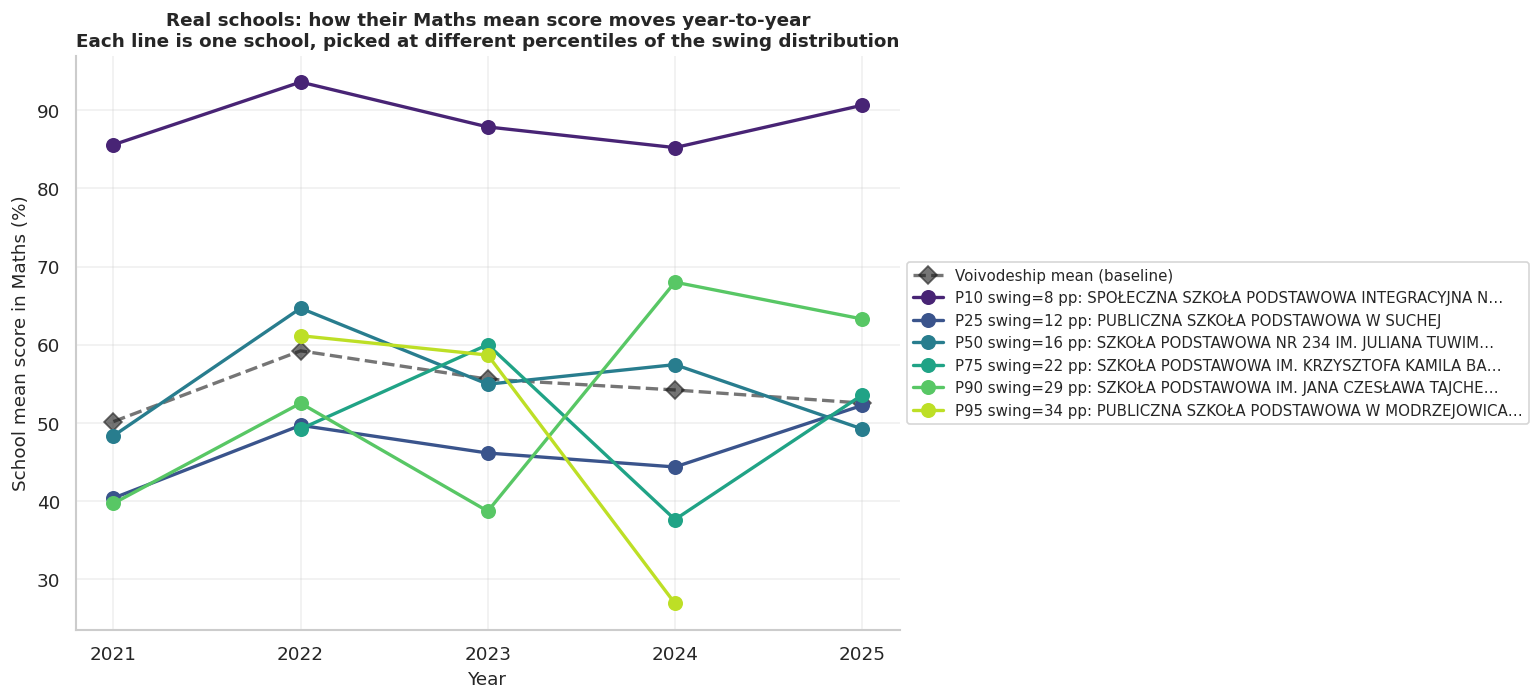


Table of the picked schools:


,school_name,n_years,min_mean,max_mean,swing (pp),mean_n_students
percentile,,,,,,
P10,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 10...,5,85.2,93.6,8.4,25.8
P25,PUBLICZNA SZKOŁA PODSTAWOWA W SUCHEJ,5,40.3,52.2,11.9,20.4
P50,SZKOŁA PODSTAWOWA NR 234 IM. JULIANA TUWIMA,5,48.3,64.7,16.3,47.4
P75,SZKOŁA PODSTAWOWA IM. KRZYSZTOFA KAMILA BACZYŃ...,4,37.6,60.0,22.4,8.2
P90,SZKOŁA PODSTAWOWA IM. JANA CZESŁAWA TAJCHERTA ...,5,38.7,68.0,29.3,10.2
P95,PUBLICZNA SZKOŁA PODSTAWOWA W MODRZEJOWICACH,3,26.9,61.1,34.3,6.7


In [13]:
# ── Concrete examples: real schools with various swing magnitudes ────────────
# Compute swing per school (Maths)
SUBJ_FOR_EXAMPLES = 'matematyka'
rng_per_school = (
    df_swing.groupby('rspo')[f'mean_{SUBJ_FOR_EXAMPLES}']
    .agg(lambda x: x.max() - x.min())
    .dropna()
    .sort_values()
)

n_total = len(rng_per_school)

# Pick representative schools at given percentile positions
PICK_PCTS = [10, 25, 50, 75, 90, 95]
picks = []
for p in PICK_PCTS:
    idx_pos = int(n_total * p / 100)
    rspo = rng_per_school.index[idx_pos]
    picks.append((p, rspo, rng_per_school.iloc[idx_pos]))

# Plot each school's mean trajectory across years
fig, ax = plt.subplots(figsize=(13, 6))

years_all = sorted(df_swing['year'].unique())
voi_mean_per_year = df_swing.groupby('year')[f'mean_{SUBJ_FOR_EXAMPLES}'].mean()
ax.plot(years_all, voi_mean_per_year.values, 'k--', lw=2,
        marker='D', markersize=8, label='Voivodeship mean (baseline)', alpha=0.6)

cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(picks)))
for (pct, rspo, swing), color in zip(picks, cmap):
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    name = school_data['school_name'].iloc[0]
    # Truncate long names
    name_short = name[:42] + '…' if len(name) > 42 else name
    ax.plot(school_data['year'], school_data[f'mean_{SUBJ_FOR_EXAMPLES}'],
            marker='o', lw=2, color=color, markersize=8,
            label=f'P{pct} swing={swing:.0f} pp: {name_short}')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(f'School mean score in {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} (%)', fontsize=11)
ax.set_title(
    f'Real schools: how their {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} mean score moves year-to-year\n'
    f'Each line is one school, picked at different percentiles of the swing distribution',
    fontsize=11, fontweight='bold')
ax.set_xticks(years_all)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table summary
print('\nTable of the picked schools:')
rows = []
for pct, rspo, swing in picks:
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    rows.append({
        'percentile': f'P{pct}',
        'school_name': school_data['school_name'].iloc[0],
        'n_years': len(school_data),
        'min_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].min(), 1),
        'max_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].max(), 1),
        'swing (pp)': round(swing, 1),
        'mean_n_students': round(school_data[f'n_{SUBJ_FOR_EXAMPLES}'].mean(), 1),
    })
display(pd.DataFrame(rows).set_index('percentile'))

## Picking the best metric — LOO stability test

We now have to choose *which* per-year metric to use as our normalised score.
Below are the candidates. For each school in each year we can compute:

| Metric | Description |
|--------|-------------|
| `mean` | Average student score |
| `median` | Middle student's score (less sensitive to outliers) |
| `diff_avg` | School mean - voivodeship mean for that year |
| `diff_med` | School median - voivodeship median for that year |
| `unit_norm_diff_avg` | `diff_avg` divided by the distance to the ceiling (if positive) or floor (if negative). Result in [-1, +1] |
| `unit_norm_diff_med` | Same logic using `diff_med` |
| `pct_mean` | Percentile rank of the school mean in that year (across all schools) |
| `pct_median` | Percentile rank of the school median in that year |

## How we choose

We use **jackknife (leave-one-out) stability**: for a school with N years of data,
we compute the metric N times, each time leaving out one year. The more the result
changes, the less stable the metric — and a less stable metric means the score is
driven by luck (which year happened to be included) rather than real school quality.

We want the metric where the N estimates are *closest together* — measured by the
**LOO standard deviation**, normalised by the metric's overall spread across all
schools, so that metrics on different scales can be compared.

In [129]:
# Compute voivodeship median per year per subject (used for diff_median)
voivodeship_median = {}
for subject_code in core_short:
    voivodeship_median[subject_code] = df.groupby('year')[f'median_{subject_code}'].median()
    df[f'voivodeship_median_{subject_code}'] = df['year'].map(voivodeship_median[subject_code])
    df[f'diff_median_{subject_code}'] = df[f'median_{subject_code}'] - df[f'voivodeship_median_{subject_code}']

# Compute percentile ranks within each year for mean and median
for subject_code in core_short:
    for metric in ['median', 'mean']:
        input_column  = f'{metric}_{subject_code}'
        output_column = f'pct_{metric}_{subject_code}'
        df[output_column] = df.groupby('year')[input_column].transform(
            lambda x: stats.rankdata(x.fillna(x.median()), method='average') / len(x) * 100
        )

# ── Compute additional candidate metrics: diff_avg, unit_norm_diff_avg, unit_norm_diff_med ─
voivodeship_mean = {}
for subject in core_short:
    voivodeship_mean[subject] = df.groupby('year')[f'mean_{subject}'].mean()
    df[f'voivodeship_mean_{subject}'] = df['year'].map(voivodeship_mean[subject])
    df[f'diff_avg_{subject}'] = df[f'mean_{subject}'] - df[f'voivodeship_mean_{subject}']

    # unit_norm_diff: signed normalisation to [-1, +1] using ceiling/floor distance
    # unit_norm_diff_avg uses mean-based diff and voivodeship mean as reference
    d_avg = df[f'diff_avg_{subject}']
    v_avg = df[f'voivodeship_mean_{subject}']
    df[f'unit_norm_diff_avg_{subject}'] = np.where(
        d_avg >= 0,
        d_avg / (100 - v_avg).where(100 - v_avg > 0, 1),
        d_avg / v_avg.where(v_avg > 0, 1),
    )

    # unit_norm_diff_med uses median-based diff and voivodeship median as reference
    median_diffs = df[f'diff_median_{subject}']
    median_values = df[f'voivodeship_median_{subject}']
    df[f'unit_norm_diff_med_{subject}'] = np.where(
        median_diffs >= 0,
        median_diffs / (100 - median_values).where(100 - median_values > 0, 1),
        median_diffs / median_values.where(median_values > 0, 1),
    )

print('Candidate metrics computed for each (school, year, subject) row:')
print('  diff_median, diff_avg, pct_mean, pct_median, unit_norm_diff_avg, unit_norm_diff_med')
print('(mean, median already exist from earlier cells)')

Candidate metrics computed for each (school, year, subject) row:
  diff_median, diff_avg, pct_mean, pct_median, unit_norm_diff_avg, unit_norm_diff_med
(mean, median already exist from earlier cells)


In [ ]:
# ── Jackknife LOO stability ───────────────────────────────────────────────────
# Only use schools with data in at least 3 years
years_per_school = df.groupby('rspo')['year'].nunique()
df_multi = df[df['rspo'].isin(years_per_school[years_per_school >= 3].index)].copy()

CANDIDATE_METRICS = {
    'mean':           lambda s: f'mean_{s}',
    'median':         lambda s: f'median_{s}',
    'diff_avg':       lambda s: f'diff_avg_{s}',
    'diff_med':       lambda s: f'diff_median_{s}',
    'unit_norm_diff_avg':  lambda s: f'unit_norm_diff_avg_{s}',
    'unit_norm_diff_med':  lambda s: f'unit_norm_diff_med_{s}',
    'pct_mean':       lambda s: f'pct_mean_{s}',
    'pct_median':     lambda s: f'pct_median_{s}',
}

loo_records = []
for school_rspo, school_df in df_multi.groupby('rspo'):
    school_df = school_df.sort_values('year').reset_index(drop=True)
    school_year_count = len(school_df)

    for subject in core_short:
        n_vals = school_df[f'n_{subject}'].values
        if np.any(np.isnan(n_vals)) or n_vals.sum() == 0:
            continue

        rec = {'rspo': school_rspo, 'subject': subject, 'mean_n': n_vals.mean(),
               'median_n': float(np.median(n_vals)), 'n_years': school_year_count}

        for metric_name, column_getter in CANDIDATE_METRICS.items():
            m_vals = school_df[column_getter(subject)].values
            if np.any(np.isnan(m_vals)):
                continue
            loo_scores = []
            for fold_index in range(school_year_count):
                mask = np.ones(school_year_count, dtype=bool); mask[fold_index] = False
                students_subset = n_vals[mask]; total_students = students_subset.sum()
                if total_students == 0: continue
                loo_scores.append((students_subset * m_vals[mask]).sum() / total_students)
            if len(loo_scores) >= 2:
                rec[f'loo_std_{metric_name}'] = np.std(loo_scores)
        loo_records.append(rec)

loo = pd.DataFrame(loo_records)

# Normalise LOO std by the metric's overall spread (so metrics with different scales are comparable)
for subject in core_short:
    sub_mask = loo['subject'] == subject
    for metric_name, column_getter in CANDIDATE_METRICS.items():
        overall_std = df_multi[column_getter(subject)].std()
        loo.loc[sub_mask, f'rel_{metric_name}'] = (
            loo.loc[sub_mask, f'loo_std_{metric_name}'] / overall_std
        )

# Size bin from median_n (more stable than mean_n)
loo['size_bin'] = pd.cut(
    loo['median_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+'],
)

print(f'LOO computed for {len(loo):,} school-subject pairs across {loo["rspo"].nunique():,} schools')

LOO computed for 4,713 school-subject pairs across 1,571 schools


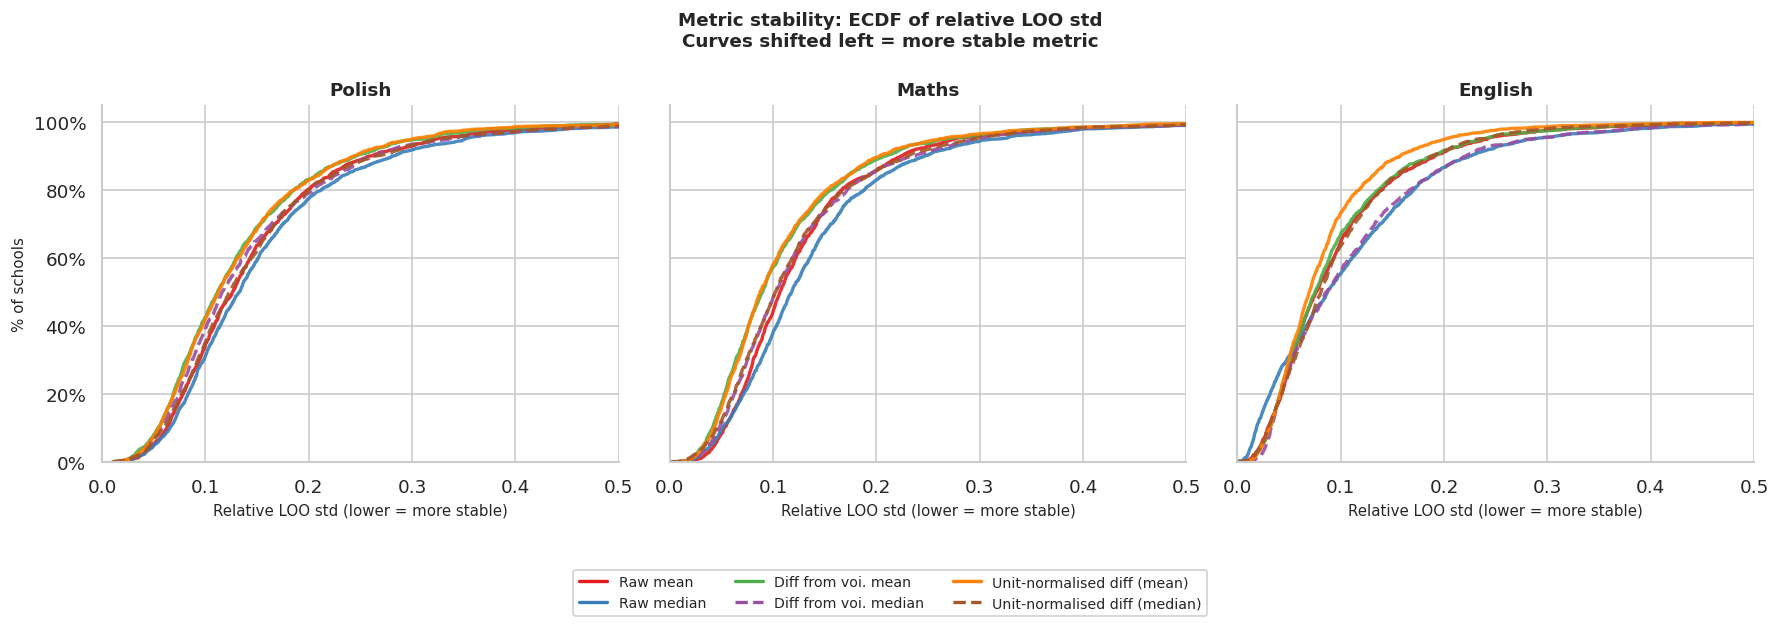

In [17]:
# ── Plot: ECDF of relative LOO std per metric, per subject ───────────────────
METRIC_DISPLAY = {
    'mean':           ('Raw mean',                 '#e41a1c', '-'),
    'median':         ('Raw median',               '#377eb8', '-'),
    'diff_avg':       ('Diff from voi. mean',      '#4daf4a', '-'),
    'diff_med':       ('Diff from voi. median',    '#984ea3', '--'),
    'unit_norm_diff_avg':  ('Unit-normalised diff (mean)',   '#ff7f00', '-'),
    'unit_norm_diff_med':  ('Unit-normalised diff (median)', '#a65628', '--'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, subject in zip(axes, core_short):
    sub = loo[loo['subject'] == subject]
    for metric_name, (label, color, ls) in METRIC_DISPLAY.items():
        col = f'rel_{metric_name}'
        if col not in sub.columns: continue
        x = np.sort(sub[col].dropna().values)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, label=label, color=color, lw=2, ls=ls, alpha=0.9)

    label_subj = SUBJECT_LABELS[subject]
    ax.set_title(label_subj, fontsize=11, fontweight='bold')
    ax.set_xlabel('Relative LOO std (lower = more stable)', fontsize=9)
    ax.set_xlim(0, 0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of schools', fontsize=9)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
axes[0].set_ylim(0, 105)

handles = [mlines.Line2D([], [], color=c, lw=2, ls=ls, label=label)
           for label, c, ls in METRIC_DISPLAY.values()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8.5,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    'Metric stability: ECDF of relative LOO std\n'
    'Curves shifted left = more stable metric',
    fontsize=11, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

In [18]:
# ── Summary table: median relative LOO std per (subject, size bin) ───────────
rel_cols = [f'rel_{m}' for m in METRIC_DISPLAY]

for subject in core_short:
    sub = loo[loo['subject'] == subject]
    agg = sub.groupby('size_bin', observed=True)[rel_cols].median().round(3)
    agg.columns = list(METRIC_DISPLAY.keys())
    label_subj = SUBJECT_LABELS[subject]
    print(f'-- {label_subj} --')
    display(agg.style
            .highlight_min(axis=1, color='#c6efce')
            .set_caption(f'{label_subj}: green = most stable metric for that school size'))

-- Polish --


,mean,median,diff_avg,diff_med,unit_norm_diff_avg,unit_norm_diff_med
size_bin,,,,,,
1–9,0.215000,0.250000,0.227000,0.235000,0.207000,0.215000
10–19,0.157000,0.168000,0.150000,0.155000,0.145000,0.157000
20–49,0.112000,0.119000,0.102000,0.107000,0.101000,0.111000
50–99,0.096000,0.101000,0.078000,0.085000,0.087000,0.099000
100+,0.083000,0.085000,0.069000,0.072000,0.077000,0.088000


-- Maths --


,mean,median,diff_avg,diff_med,unit_norm_diff_avg,unit_norm_diff_med
size_bin,,,,,,
1–9,0.194000,0.202000,0.191000,0.200000,0.183000,0.192000
10–19,0.135000,0.141000,0.122000,0.129000,0.120000,0.128000
20–49,0.099000,0.111000,0.080000,0.094000,0.079000,0.094000
50–99,0.083000,0.098000,0.057000,0.073000,0.062000,0.075000
100+,0.080000,0.096000,0.046000,0.061000,0.054000,0.075000


-- English --


,mean,median,diff_avg,diff_med,unit_norm_diff_avg,unit_norm_diff_med
size_bin,,,,,,
1–9,0.183000,0.197000,0.174000,0.201000,0.135000,0.144000
10–19,0.112000,0.137000,0.110000,0.132000,0.089000,0.096000
20–49,0.069000,0.082000,0.070000,0.080000,0.063000,0.075000
50–99,0.050000,0.047000,0.046000,0.049000,0.052000,0.066000
100+,0.037000,0.028000,0.037000,0.038000,0.046000,0.046000


**Finding:** `diff_avg` and `unit_norm_diff_avg` are the most stable metrics across all
three subjects and all school sizes ≥ 10 students. The two correlate at Spearman 1.000
— they produce identical rankings, just with different scales. `diff_avg` is in
percentage points (interpretable: "5 pp above the voivodeship mean"); `unit_norm_diff_avg`
is in [-1, +1] (interpretable: "halfway between the voivodeship mean and the ceiling").

For very small schools (< 10 students) the differences between metrics shrink — all
metrics are noisy at that size because the sample is so small. The 0.15 pp gap visible
in the table is well within the sampling noise we documented above.

`diff_med` (using median) is consistently *worse* than `diff_avg`. This was a surprise:
our intuition was that the median should be more robust because it ignores outliers
within a school. But the analysis above showed that the median *jumps more* in
response to year-to-year difficulty changes, and that within-school medians swing
47-59% wider than means across years. The mean uses all student scores and is
empirically more stable.

We use **`unit_norm_diff_avg`** as the primary metric and expose `diff_avg` as a secondary
view in the app. The [-1, +1] scale is more stable across years than pp (sigma values
don't drift when new years are added) and supports a fixed-threshold colour scale
on the map.

## 4. Aggregating across years

We have up to 5 years of data per school. We need to combine them into one number.

Three natural options:
- **Weighted mean** — weight each year by the number of students sitting the exam
- **Median of years** — take the middle year's result (ignores how many students)
- **Trimmed mean** — drop the best and worst year, average the rest

We apply the same jackknife test: which aggregation gives the most stable
school score when we drop one year?

In [19]:
# For schools with 5 years of data: LOO stability of aggregation methods
# Use the winning per-year metric (unit_norm_diff_avg) as input
year_count_5 = df.groupby('rspo')['year'].nunique()
df5 = df[df['rspo'].isin(year_count_5[year_count_5 == 5].index)].copy()

aggregation_records = []
for rspo, grp in df5.groupby('rspo'):
    grp = grp.sort_values('year').reset_index(drop=True)
    for subject in core_short:
        n_vals = grp[f'n_{subject}'].values
        m_vals = grp[f'unit_norm_diff_avg_{subject}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(m_vals)):
            continue

        loo_wmean, loo_median, loo_trimmed = [], [], []
        for fold_index in range(5):
            mask = np.ones(5, dtype=bool); mask[fold_index] = False
            students_subset = n_vals[mask]; m_sub = m_vals[mask]; total_students = students_subset.sum()
            if total_students == 0: continue
            loo_wmean.append((students_subset * m_sub).sum() / total_students)
            loo_median.append(np.median(m_sub))
            loo_trimmed.append(np.sort(m_sub)[1:3].mean())  # 4 values → drop min/max, mean middle 2

        if len(loo_wmean) >= 4:
            aggregation_records.append({
                'rspo': rspo, 'subject': subject, 'mean_n': n_vals.mean(),
                'std_weighted_mean':      np.std(loo_wmean),
                'std_median_across_years': np.std(loo_median),
                'std_trimmed':    np.std(loo_trimmed),
            })

leave_one_out_aggregation = pd.DataFrame(aggregation_records)
leave_one_out_aggregation['size_bin'] = pd.cut(
    leave_one_out_aggregation['mean_n'], bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+'],
)

aggregation_summary = (
    leave_one_out_aggregation.groupby('size_bin', observed=True)[['std_weighted_mean', 'std_median_across_years', 'std_trimmed']]
    .median()
    .rename(columns={
        'std_weighted_mean':      'Weighted mean (by n)',
        'std_median_across_years': 'Median of years',
        'std_trimmed':    'Trimmed mean',
    }).round(3)
)
print('Median LOO std for aggregation methods (using unit_norm_diff_avg as input):')
display(aggregation_summary.style.highlight_min(axis=1, color='#c6efce')
        .set_caption('Green = most stable aggregation for that school size'))

Median LOO std for aggregation methods (using unit_norm_diff_avg as input):


,Weighted mean (by n),Median of years,Trimmed mean
size_bin,,,
1–9,0.040000,0.045000,0.045000
10–19,0.030000,0.030000,0.030000
20–49,0.023000,0.024000,0.024000
50–99,0.019000,0.021000,0.021000
100+,0.017000,0.016000,0.016000


**Finding:** Weighted mean (weighting each year by number of students)
is the most stable or tied-most-stable for all school sizes.
It also has the best intuitive justification: a year where 50 students sat the exam
should count more than a year where only 5 did.

**Final per-subject score formula:**
```
score(school, subject) = Σ(n_year × diff_year) / Σ(n_year)

where diff_year = school_median_year − voivodeship_median_year
```
This gives a number in percentage points: positive means above average for the country,
negative means below average, zero means exactly at the voivodeship median.

In [20]:
# ── Compute final per-subject score for every school ────────────────────────
# Primary metric: unit_norm_diff_avg.  Also export diff_avg, median, mean as alternatives.
PRIMARY_METRIC   = 'unit_norm_diff_avg'
SECONDARY_METRICS = ['diff_avg', 'median', 'mean']

score_records = []
for rspo, grp in df.groupby('rspo'):
    row = {
        'rspo':        rspo,
        'school_name': grp['school_name'].iloc[0],
        'is_public':   grp['is_public'].iloc[0],
        'n_years':     grp['year'].nunique(),
        'years':       sorted(grp['year'].unique().tolist()),
    }
    for subject in core_short:
        student_counts = pd.to_numeric(grp[f'n_{subject}'], errors='raise')
        valid = (student_counts > 0) & student_counts.notna()
        if valid.sum() == 0: continue
        n_arr = student_counts[valid].values
        total_students = n_arr.sum()

        for metric in [PRIMARY_METRIC] + SECONDARY_METRICS:
            col = f'{metric}_{subject}'
            if col not in grp.columns: continue
            m_arr = pd.to_numeric(grp[col], errors='raise')[valid].values
            if np.any(np.isnan(m_arr)): continue
            row[f'{metric}_{subject}'] = (n_arr * m_arr).sum() / total_students

        row[f'n_total_{subject}'] = int(total_students)
        row[f'n_years_{subject}'] = int(valid.sum())
    score_records.append(row)

scores = pd.DataFrame(score_records)
scores = scores.dropna(subset=[f'{PRIMARY_METRIC}_{s}' for s in core_short])

# Percentile ranks of the primary metric (for map colour)
for subject in core_short:
    col = f'{PRIMARY_METRIC}_{subject}'
    scores[f'pct_{subject}'] = (
        stats.rankdata(scores[col], method='average') / len(scores) * 100
    )

# Sigma per subject for colour scale
sigma = {subject: scores[f'{PRIMARY_METRIC}_{subject}'].std() for subject in core_short}
print(f'Sigma per subject (based on {PRIMARY_METRIC}):')
for subject in core_short:
    label_subj = SUBJECT_LABELS.get(subject, subject)
    print(f'  {label_subj:10s}: σ = {sigma[subject]:.4f}   '
          f'(saturate at ±{1.5 * sigma[subject]:.2f})')

print(f'\nSchools with scores: {len(scores):,}')

Sigma per subject (based on unit_norm_diff_avg):
  Polish    : σ = 0.1919   (saturate at ±0.29)
  Maths     : σ = 0.2843   (saturate at ±0.43)
  English   : σ = 0.3611   (saturate at ±0.54)

Schools with scores: 1,720


## 5. Which schools are consistently at the top?

Because individual years are noisy, we want to check that the top schools
are not just lucky — they should appear at the top across *multiple* LOO folds.

For each school we compute: how often does it appear in the top N
when we drop one year at a time? A school that is *always* in the top 30
is more trustworthy than one that is there only when one particular year is included.

In [21]:
# Jackknife stability of school ranking (Maths, schools with 5 years)
TOP_N_LIST = [5, 10, 30, 50]

def loo_scores(rspo_grp_iter, subject_code: str) -> dict:
    """Return {rspo: [score_loo_0, score_loo_1, ...]} for all schools."""
    result = {}
    for rspo, grp in rspo_grp_iter:
        grp = grp.sort_values('year').reset_index(drop=True)
        n_vals   = grp[f'n_{subject_code}'].values
        diff_vals= grp[f'diff_median_{subject_code}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(diff_vals)):
            continue
        year_count = len(grp)
        loos = []
        for fold_index in range(year_count):
            mask  = np.ones(year_count, dtype=bool); mask[fold_index] = False
            students_subset = n_vals[mask]; total_students = students_subset.sum()
            if total_students == 0: continue
            loos.append((students_subset * diff_vals[mask]).sum() / total_students)
        if loos:
            result[rspo] = loos
    return result


subject_code = 'matematyka'  # show for Maths; pattern is similar for other subjects
loo_vals = loo_scores(df5.groupby('rspo'), subject_code)

# For each LOO fold, rank all schools and record top-N membership
n_folds = 5
all_rspo = list(loo_vals.keys())

# Matrix: rows=schools, cols=folds, value=score
fold_matrix = pd.DataFrame(
    {rspo: {f: values[f] if f < len(values) else np.nan for f in range(n_folds)}
     for rspo, values in loo_vals.items()}
).T  # shape: (n_schools, 5)

consistency_rows = []
name_lu = df5.groupby('rspo')['school_name'].first()

for rspo in fold_matrix.index:
    row = {'rspo': rspo, 'school_name': name_lu.get(rspo, '?')}
    full_score = fold_matrix.loc[rspo].mean()  # mean across LOO folds ≈ full score
    row['mean_score'] = full_score
    for top_n in TOP_N_LIST:
        count_in_top = 0
        for fold in range(n_folds):
            fold_scores = fold_matrix[fold].dropna()
            rank = (fold_scores > fold_matrix.loc[rspo, fold]).sum() + 1
            if rank <= top_n:
                count_in_top += 1
        row[f'in_top_{top_n}_of_{n_folds}'] = count_in_top
    consistency_rows.append(row)

consistency = pd.DataFrame(consistency_rows).sort_values('mean_score', ascending=False)

print(f'Schools consistently in the top (Maths, schools with 5 years of data):')
display(
    consistency.head(40)[[
        'school_name', 'mean_score',
        f'in_top_5_of_{n_folds}', f'in_top_10_of_{n_folds}',
        f'in_top_30_of_{n_folds}', f'in_top_50_of_{n_folds}',
    ]].rename(columns={
        'mean_score':                'Avg score (pp above voivodeship)',
        f'in_top_5_of_{n_folds}':   f'In top 5 / {n_folds} folds',
        f'in_top_10_of_{n_folds}':  f'In top 10 / {n_folds} folds',
        f'in_top_30_of_{n_folds}':  f'In top 30 / {n_folds} folds',
        f'in_top_50_of_{n_folds}':  f'In top 50 / {n_folds} folds',
    }).style.background_gradient(cmap='Greens', subset=[f'In top 5 / {n_folds} folds',
                                                         f'In top 10 / {n_folds} folds'])
)

Schools consistently in the top (Maths, schools with 5 years of data):


,school_name,Avg score (pp above voivodeship),In top 5 / 5 folds,In top 10 / 5 folds,In top 30 / 5 folds,In top 50 / 5 folds
1063,"SZKOŁA PODSTAWOWA PRZY SPOŁECZNYM LICEUM OGÓLNOKSZTAŁCĄCYM NR 4 IM. BATALIONU AK ""PARASOL""",43.591733,5,5,5,5
327,"PRYWATNA SZKOŁA PODSTAWOWA NR 81 FUNDACJI ""RODZICE DZIECIOM""",43.404227,5,5,5,5
244,PRYWATNA SZKOŁA PODSTAWOWA NR 6 SIÓSTR NIEPOKALANEK IM. BŁ. M. MARCELINY DAROWSKIEJ,43.369818,5,5,5,5
489,SZKOŁA PODSTAWOWA NR 3 PRZYMIERZA RODZIN IM. BŁOGOSŁAWIONEGO KS. JERZEGO POPIEŁUSZKI,42.674575,2,5,5,5
336,PRYWATNA SZKOŁA PODSTAWOWA NR 92,42.651022,3,5,5,5
347,PRYWATNA SZKOŁA PODSTAWOWA NR 51 IM. JANA BRZECHWY,42.623601,2,5,5,5
242,SPOŁECZNA SZKOŁA PODSTAWOWA NR 10 IM.KARDYNAŁA STEFANA WYSZYŃSKIEGO SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,42.186227,1,4,5,5
315,"NIEPUBLICZNA SZKOŁA PODSTAWOWA NR 47 IM. ROBERTA SCHUMANA FUNDACJI ""PRIMUS""",41.742176,0,4,5,5
338,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 100 SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,41.702871,0,2,5,5
305,SPOŁECZNA SZKOŁA PODSTAWOWA NR 16 SPOŁECZNEGOTOWARZYSTWA OŚWIATOWEGO,41.674884,1,2,5,5


## 6. Combining all three subjects

A school could score well in Maths but poorly in Polish. How do we combine
the three subject scores into a single number for the map?

First, we check how correlated the three subjects are.
If they are highly correlated, the choice of combination method barely matters.
If they are independent, we need to be careful.

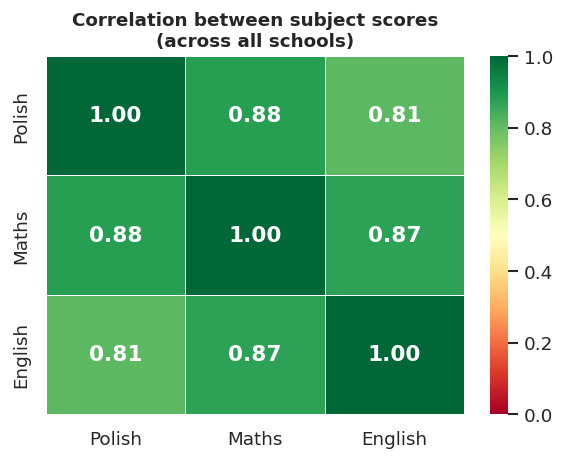


Spearman rank correlation (more robust to outliers):
         Polish  Maths  English
Polish     1.00   0.84     0.78
Maths      0.84   1.00     0.84
English    0.78   0.84     1.00


In [22]:
# ── Subject correlation ───────────────────────────────────────────────────────
score_cols = [f'unit_norm_diff_avg_{s}' for s in core_short]
corr = scores[score_cols].rename(
    columns={f'unit_norm_diff_avg_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('Correlation between subject scores\n(across all schools)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSpearman rank correlation (more robust to outliers):')
print(scores[score_cols].rename(
    columns={f'unit_norm_diff_avg_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr(method='spearman').round(2))

Schools good in all 3 subjects (≥60th percentile each): 496
  of which public:   332
  of which private:  164


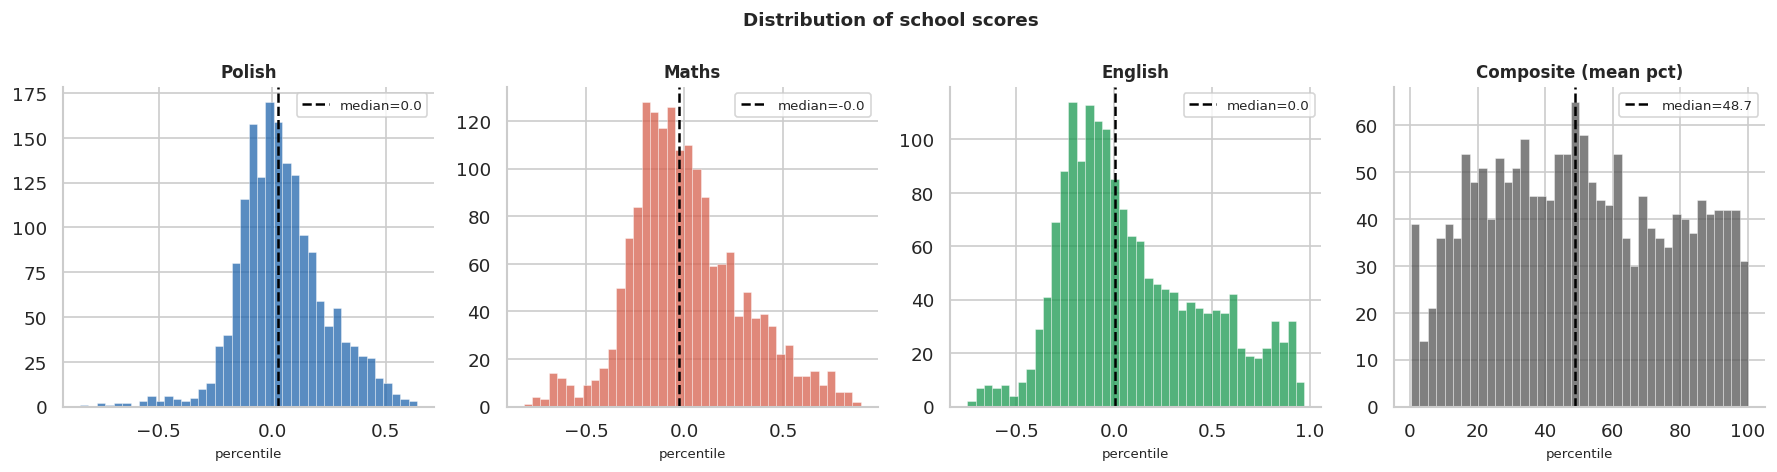

In [23]:
# ── Composite score: mean of per-subject percentiles ─────────────────────────
scores['composite_percentile'] = scores[[f'pct_{s}' for s in core_short]].mean(axis=1)

scores['good_in_all_3'] = (
    (scores['pct_polski']    >= 60) &
    (scores['pct_matematyka']>= 60) &
    (scores['pct_angielski'] >= 60)
)

print(f'Schools good in all 3 subjects (≥60th percentile each): {scores["good_in_all_3"].sum()}')
print(f'  of which public:   {(scores["good_in_all_3"] & (scores["is_public"]=="Tak")).sum()}')
print(f'  of which private:  {(scores["good_in_all_3"] & (scores["is_public"]=="Nie")).sum()}')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

subjects_to_plot = [
    (f'unit_norm_diff_avg_{s}', SUBJECT_LABELS.get(s, s), SUBJECT_COLORS[s])
    for s in core_short
]
subjects_to_plot.append(('composite_percentile', 'Composite (mean pct)', '#555555'))

for ax, (col, label, color) in zip(axes, subjects_to_plot):
    data = scores[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(data.median(), color='black', lw=1.5, ls='--', label=f'median={data.median():.1f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('pp above/below voivodeship' if 'score' in col else 'percentile', fontsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of school scores', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Final metric definition

Based on the analysis above, here is the metric used for the school quality map.

### Per-subject score

```
diff_year(school, subject, year) =
    median_score(school, subject, year) − voivodeship_median(subject, year)

score(school, subject) =
    Σ_year [ n_students(year) × diff_year ] / Σ_year [ n_students(year) ]
```

This gives a number in percentage points:
- **+10 pp** means the middle student at this school scores 10 points above
  the middle student voivodeshiply, averaged over all available years.
- **−5 pp** means the school is below average by 5 points.

### Why this metric?

1. **Difference from voivodeship median** removes the year-difficulty effect
   (the 14 pp swing in Maths difficulty between 2021 and 2022 is neutralised).
2. **Median** is preferred over mean because outlier students
   (one gifted or one struggling child) affect the mean more than the median.
3. **Weighted by student count** means a year with 50 students carries
   more weight than a year with 5, which is statistically correct.
4. The metric is **not a percentile** — a school 10 pp above average gets that
   number regardless of whether 300 or 3 other schools are also around that level.
   Percentile is used only for colouring the map markers.

### Map colour scale

The marker colour on the map is a diverging green–yellow–red gradient:
- **Yellow** = within ±0.33σ of the voivodeship median (not meaningfully different)
- **Deep green** = ≥ +1.5σ above voivodeship (reliably excellent)
- **Deep red** = ≤ −1.5σ below voivodeship (reliably weak)

Schools far above +1.5σ all get the same deep green — they are all excellent,
and the difference between them is within statistical noise given the sample sizes.

### Composite score

The map also shows a composite score: the mean of the three subject percentile ranks.
Schools flagged as **good in all 3** (≥60th percentile in each subject)
are highlighted separately — this is the most conservative indicator of
all-round quality.

In [24]:
# ── Export for the map ────────────────────────────────────────────────────────
# Primary metric: unit_norm_diff_avg.  Also export diff_avg, mean, median for app toggle.
import json as _json

export_cols = ['rspo', 'school_name', 'is_public', 'n_years']
for subject in core_short:
    export_cols += [
        f'unit_norm_diff_avg_{subject}',  # primary
        f'diff_avg_{subject}',       # alternate scale (pp)
        f'median_{subject}',         # baseline 1
        f'mean_{subject}',           # baseline 2
        f'pct_{subject}',            # percentile of primary
        f'n_total_{subject}',
        f'n_years_{subject}',
    ]
export_cols += ['composite_percentile', 'good_in_all_3']

export = scores[[c for c in export_cols if c in scores.columns]].copy()

# Sigma thresholds (used by the map for colour saturation)
sigma_export = {f'sigma_unit_norm_diff_avg_{s}': round(sigma[s], 4) for s in core_short}
for s in core_short:
    sigma_export[f'sigma_diff_avg_{s}'] = round(scores[f'diff_avg_{s}'].std(), 2)

print('Sigma values for map colour scale:')
for key, value in sigma_export.items():
    print(f'  {key}: {value}')

out_path = Path('../data/school_scores.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
export.to_csv(out_path, index=False)
print(f'\nExported {len(export):,} schools to {out_path}')

sigma_path = Path('../data/sigma_thresholds.json')
sigma_path.write_text(_json.dumps(sigma_export, indent=2, ensure_ascii=False))
print(f'Exported sigma thresholds to {sigma_path}')

display(export.head(3))

Sigma values for map colour scale:
  sigma_unit_norm_diff_avg_polski: 0.1919
  sigma_unit_norm_diff_avg_matematyka: 0.2843
  sigma_unit_norm_diff_avg_angielski: 0.3611
  sigma_diff_avg_polski: 9.19
  sigma_diff_avg_matematyka: 14.01
  sigma_diff_avg_angielski: 15.87

Exported 1,720 schools to ../data/school_scores.csv
Exported sigma thresholds to ../data/sigma_thresholds.json


,rspo,school_name,is_public,n_years,unit_norm_diff_avg_polski,diff_avg_polski,median_polski,mean_polski,pct_polski,n_total_polski,...,n_years_matematyka,unit_norm_diff_avg_angielski,diff_avg_angielski,median_angielski,mean_angielski,pct_angielski,n_total_angielski,n_years_angielski,composite_pct,good_in_all_3
0,2880,PUBLICZNA SZKOŁA PODSTAWOWA IM. JANA BRZECHWY ...,Tak,4,0.093892,3.283387,72.277778,68.166667,65.290698,36,...,4,0.096759,0.669156,70.942857,67.400000,59.651163,35,4,57.325581,False
1,2970,NIEPUBLICZNA SZKOŁA PODSTAWOWA W GOŁĄBKU,Nie,2,0.061272,1.080553,64.250000,63.666667,59.186047,12,...,2,0.089045,0.422044,67.750000,66.916667,58.837209,12,2,64.263566,False
2,2985,SZKOŁA PODSTAWOWA W LIPNIE,Tak,1,-0.052123,-3.213801,60.000000,58.444444,31.511628,9,...,1,-0.308915,-20.434272,27.000000,45.714286,8.313953,7,1,23.856589,False
